In [4]:
# Flight Data Analysis Notebook
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the project root directory to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now import your module
from backend.data_processor import DataProcessor

# Load and preprocess data
data_path = "D:/flightmate/backend/datasets/clean_flight_dataset.csv"
processor = DataProcessor(data_path)
data = processor.load_data()

d:\flightmate\backend\data_processor.py:17: DtypeWarning: Columns (0,9) have mixed types. Specify dtype option on import or set low_memory=False.
  self.data = pd.read_csv(self.data_path)


In [7]:
# 1. Basic Data Exploration
print("Data Overview:")
print(data.head())
print("\nData Info:")
print(data.info())
print("\nDescriptive Statistics:")
print(data.describe())

Data Overview:
     airline flight source_city departure_time  \
0  Air India  AI868       Delhi          Other   
1  Air India  AI624       Delhi          Other   
2  Air India  AI531       Delhi          Other   
3  Air India  AI839       Delhi          Other   
4  Air India  AI544       Delhi          Other   

                                               stops arrival_time  \
0                                          non-stop         Other   
1                                          non-stop         Other   
2  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...        Other   
3  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...        Other   
4  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...        Other   

  destination_city     class  days_left    price  duration_minutes  
0           Mumbai  Business  25.663652  25612.0             120.0  
1           Mumbai  Business  25.663652  25612.0             135.0  
2           Mumbai  Business  25.663652  42220.0            14

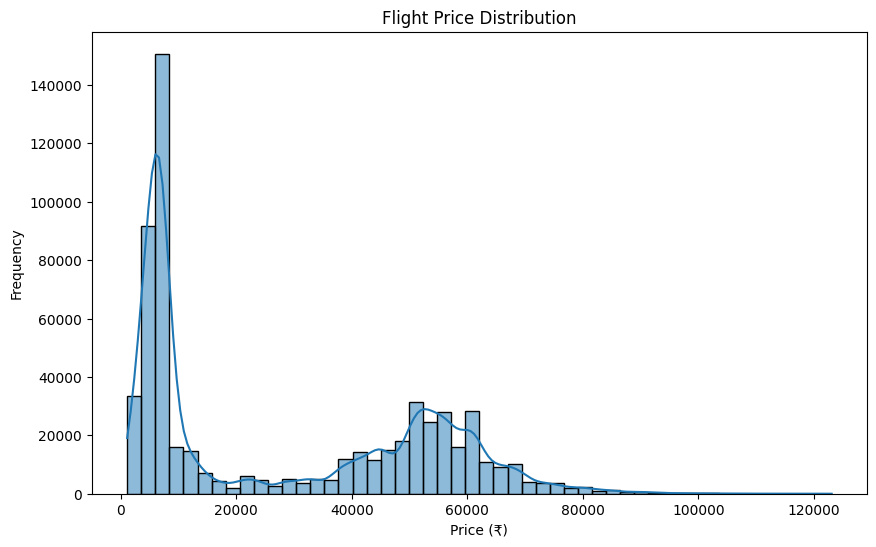

In [8]:
# 2. Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], bins=50, kde=True)
plt.title('Flight Price Distribution')
plt.xlabel('Price (₹)')
plt.ylabel('Frequency')
plt.savefig('D:/flightmate/backend/static/images/price_distribution.png')
plt.show()

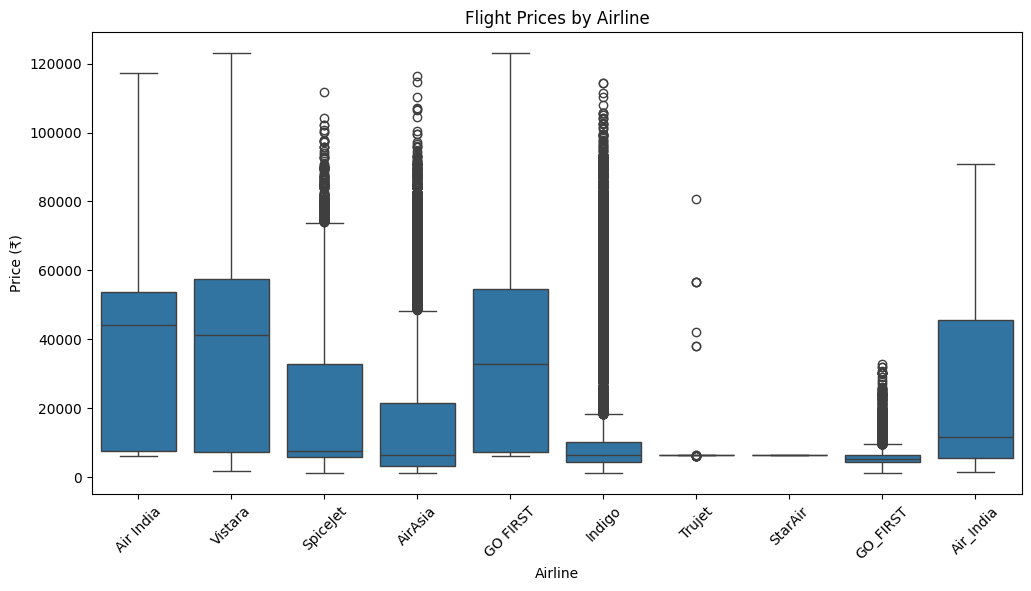

In [9]:
# 3. Price by Airline
plt.figure(figsize=(12, 6))
sns.boxplot(x='airline', y='price', data=data)
plt.title('Flight Prices by Airline')
plt.xlabel('Airline')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45)
plt.savefig('D:/flightmate/backend/static/images/price_by_airline.png')
plt.show()

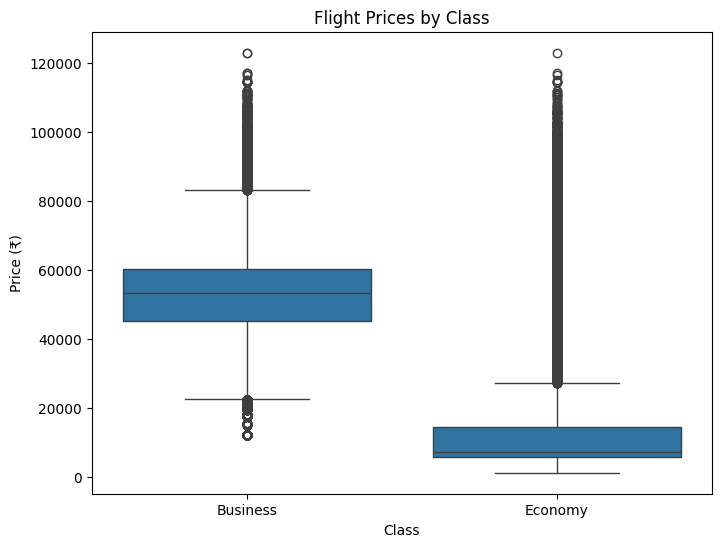

In [10]:
# 4. Price by Class
plt.figure(figsize=(8, 6))
sns.boxplot(x='class', y='price', data=data)
plt.title('Flight Prices by Class')
plt.xlabel('Class')
plt.ylabel('Price (₹)')
plt.savefig('D:/flightmate/backend/static/images/price_by_class.png')
plt.show()


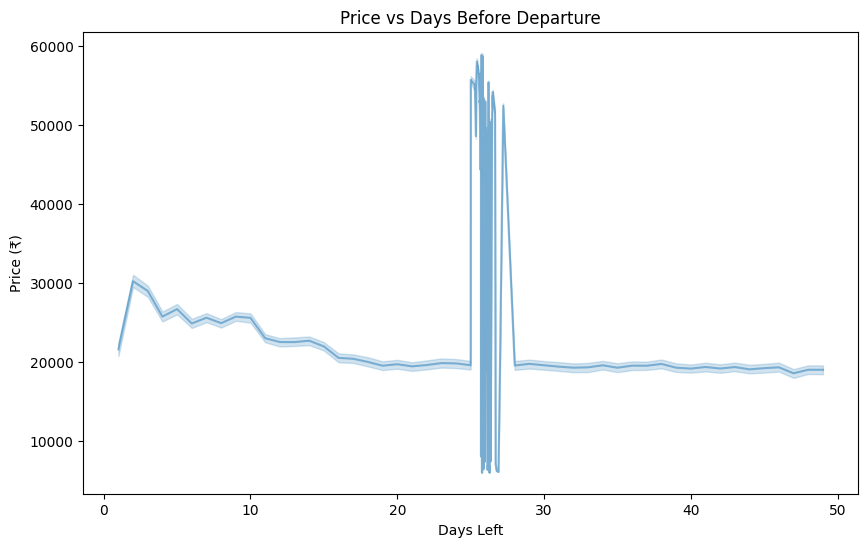

In [17]:
# 5. Price vs Days Left
plt.figure(figsize=(10, 6))
sns.lineplot(x='days_left', y='price', data=data, alpha=0.5)
plt.title('Price vs Days Before Departure')
plt.xlabel('Days Left')
plt.ylabel('Price (₹)')
plt.savefig('D:/flightmate/backend/static/images/price_vs_days_left.png')
plt.show()

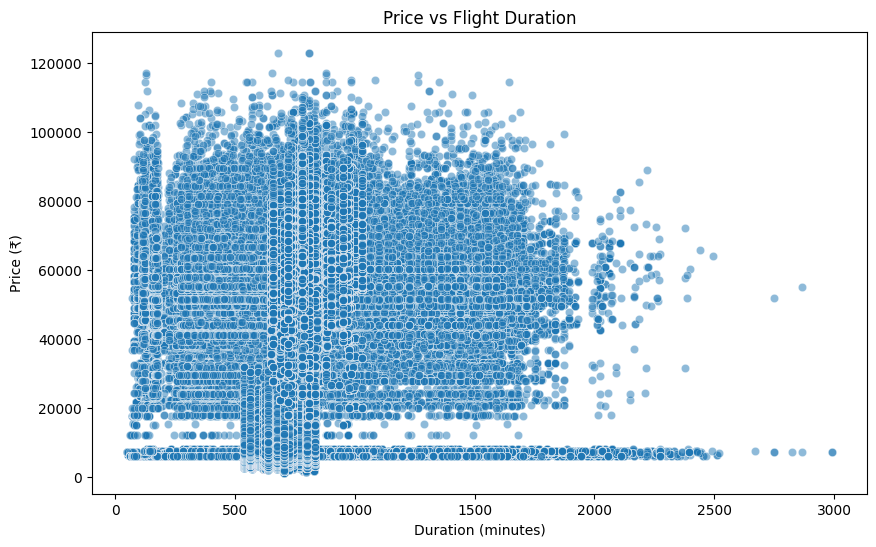

In [12]:
# 6. Price vs Duration
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_minutes', y='price', data=data, alpha=0.5)
plt.title('Price vs Flight Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Price (₹)')
plt.savefig('D:/flightmate/backend/static/images/price_vs_duration.png')
plt.show()

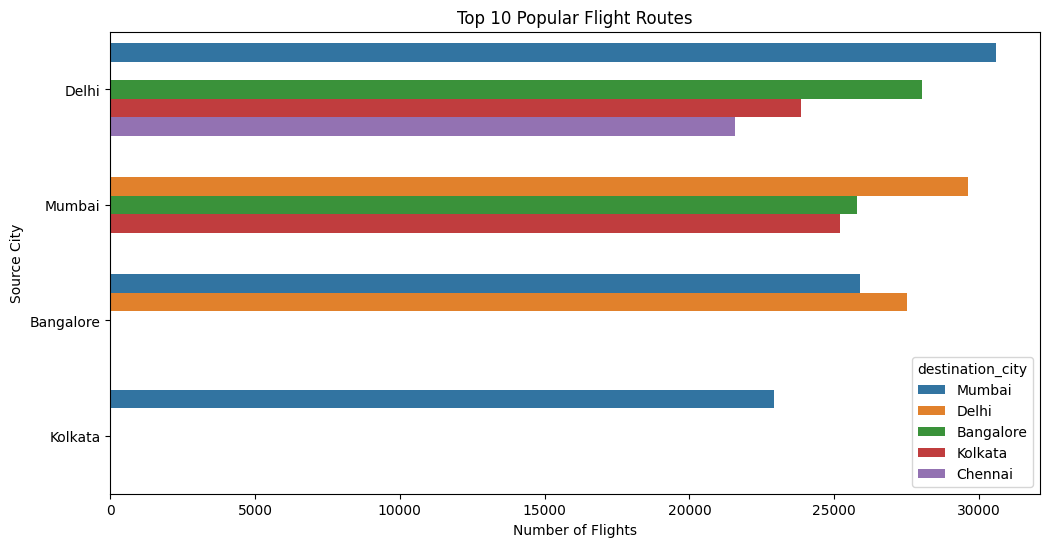

In [13]:
# 7. Popular Routes
route_counts = data.groupby(['source_city', 'destination_city']).size().reset_index(name='counts')
top_routes = route_counts.sort_values('counts', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='counts', y='source_city', hue='destination_city', data=top_routes)
plt.title('Top 10 Popular Flight Routes')
plt.xlabel('Number of Flights')
plt.ylabel('Source City')
plt.savefig('D:/flightmate/backend/static/images/top_routes.png')
plt.show()

In [20]:
data

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,days_left,price,duration_minutes
0,Air India,AI868,Delhi,Other,non-stop,Other,Mumbai,Business,25.663652,25612.0,120.000000
1,Air India,AI624,Delhi,Other,non-stop,Other,Mumbai,Business,25.663652,25612.0,135.000000
2,Air India,AI531,Delhi,Other,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Other,Mumbai,Business,25.663652,42220.0,1485.000000
3,Air India,AI839,Delhi,Other,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Other,Mumbai,Business,25.663652,44450.0,1590.000000
4,Air India,AI544,Delhi,Other,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Other,Mumbai,Business,25.663652,46690.0,400.000000
...,...,...,...,...,...,...,...,...,...,...,...
600409,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,49.000000,69265.0,950.329828
600410,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,49.000000,77105.0,950.329828
600411,Vistara,UK-832,Chennai,Morning,one,Night,Hyderabad,Business,49.000000,79099.0,950.329828
600412,Vistara,UK-828,Chennai,Morning,one,Evening,Hyderabad,Business,49.000000,81585.0,950.329828


C:\Users\Dell\AppData\Local\Temp\ipykernel_10304\1853890284.py:7: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig('D:/flightmate/backend/static/images/stops_distribution.png')
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


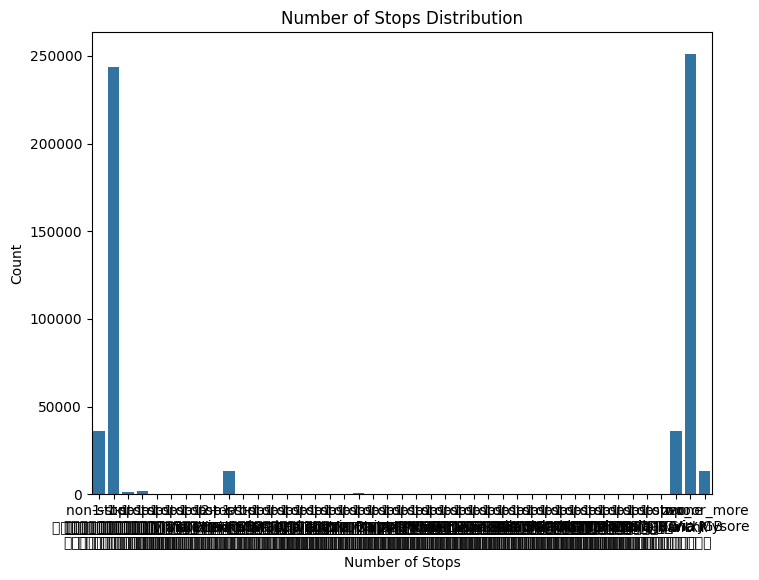

In [19]:
# 8. Stops Analysis
plt.figure(figsize=(8, 6))
sns.countplot(x='stops', data=data)
plt.title('Number of Stops Distribution')
plt.xlabel('Number of Stops')
plt.ylabel('Count')
plt.savefig('D:/flightmate/backend/static/images/stops_distribution.png')
plt.show()

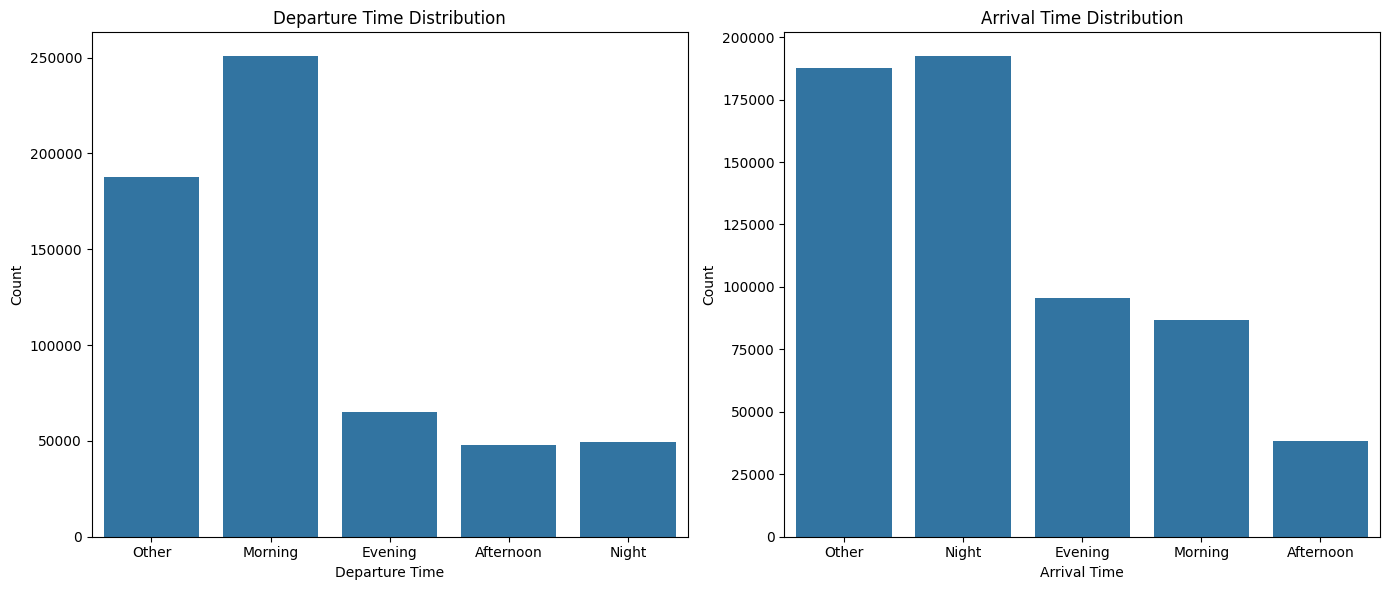

In [15]:
# 9. Time of Day Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x='departure_time', data=data, ax=axes[0])
axes[0].set_title('Departure Time Distribution')
axes[0].set_xlabel('Departure Time')
axes[0].set_ylabel('Count')

sns.countplot(x='arrival_time', data=data, ax=axes[1])
axes[1].set_title('Arrival Time Distribution')
axes[1].set_xlabel('Arrival Time')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('D:/flightmate/backend/static/images/time_distribution.png')
plt.show()


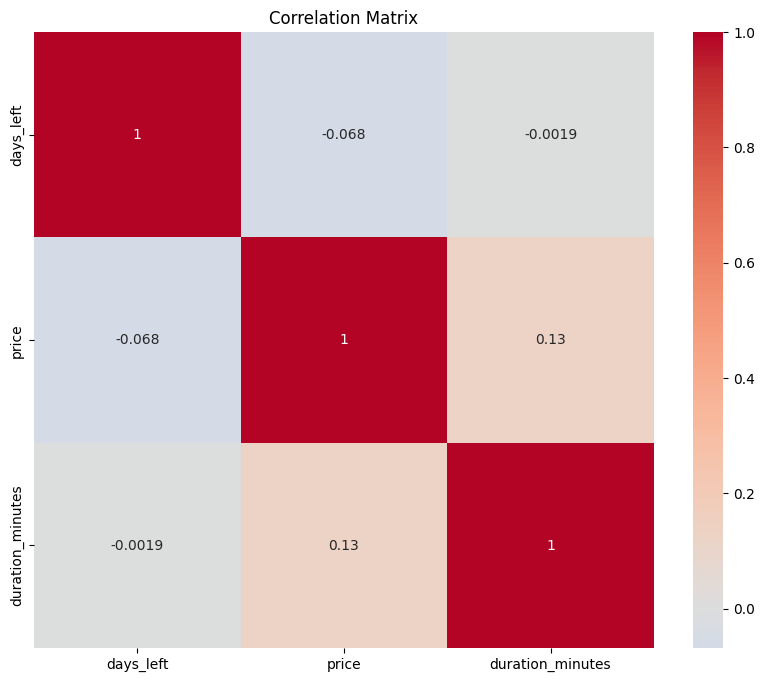

In [16]:
# 10. Correlation Analysis
numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.savefig('D:/flightmate/backend/static/images/correlation_matrix.png')
plt.show()